# 06 — Ensambles: Random Forest y XGBoost

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## Justificación del modelo (criterio oficial 5)

**El puente desde el notebook 05.** Allí quedó demostrado el problema del árbol individual: sin restricciones memoriza el train (MAE de train cercano a cero, decenas de miles de hojas) y su MAE de CV se dispara — **alta varianza**: pequeñas perturbaciones de los datos producen árboles muy distintos. La poda controla la varianza a costa de sesgo. Los ensambles atacan el mismo problema por otra vía: en lugar de un árbol recortado, **muchos árboles combinados**.

**Random Forest (bagging + decorrelación).** Promedia B árboles profundos, cada uno entrenado sobre una muestra bootstrap del train y eligiendo en cada nodo entre un subconjunto aleatorio de features (`max_features`). El promedio de B estimadores de baja correlación reduce la varianza sin aumentar el sesgo de cada árbol — exactamente el remedio para lo visto en el NB05. Bonus metodológico: cada árbol deja fuera ~37% de las observaciones (*out-of-bag*), lo que da una validación auxiliar gratuita (OOB) para contrastar con la CV.

**XGBoost (boosting).** Construye árboles **en secuencia**: cada uno corrige los residuos del ensamble acumulado, con regularización explícita (L1/L2, shrinkage por `learning_rate`, submuestreo). Donde RF reduce varianza promediando, el boosting reduce **sesgo** sumando correcciones — con el riesgo inverso (sobreajustar si se dejan crecer demasiadas rondas), mitigado por *early stopping* sobre un conjunto de validación **extraído del train**.

**Por qué NO se escala** (`build_preprocessor(scale=False)`): ambos son ensambles de árboles — los cortes por umbral son invariantes a transformaciones monótonas de cada feature (mismo argumento del NB05).

**Decisión D4 pendiente:** XGBoost puede optimizar directamente el error absoluto (`reg:absoluteerror`) — alineado con nuestra métrica de negocio — o el cuadrático clásico (`reg:squarederror`) con early stopping monitoreando MAE. La comparación empírica está más abajo y la elección queda documentada.

In [1]:
import time

import pandas as pd
from sklearn.model_selection import KFold

from src.config import DIR_PROCESSED, SEED, TARGET
from src.evaluacion import evaluar, registrar
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"train: {X_train.shape} | test: {X_test.shape}")

train: (53756, 8) | test: (20354, 8)


In [2]:
# --- 3.1 Random Forest: busqueda Optuna ---
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=100),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
        "max_depth": trial.suggest_int("max_depth", 8, 32),
    }
    p = Pipeline([
        ("preprocesador", build_preprocessor(scale=False)),
        ("modelo", RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)),
    ])
    return cross_val_score(
        p, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=1
    ).mean()

estudio_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///optuna.db", study_name="random_forest",
    load_if_exists=True,
)
# Re-ejecucion idempotente: solo se corren los trials que falten hasta 30
N_TRIALS_RF = 30
restantes = max(0, N_TRIALS_RF - len(estudio_rf.trials))
t0 = time.perf_counter()
if restantes:
    estudio_rf.optimize(objetivo_rf, n_trials=restantes, timeout=7200)
else:
    print(f"El estudio ya tiene {len(estudio_rf.trials)} trials -> "
          "no se agregan nuevos (re-ejecucion idempotente)")
t_rf_busqueda = time.perf_counter() - t0

print(f"Optuna RF: {len(estudio_rf.trials)} trials (busqueda de esta corrida: "
      f"{t_rf_busqueda/60:.1f} min)")
print(f"Mejor MAE (CV): {-estudio_rf.best_value:.4f} dias")
print(f"Mejores hiperparametros: {estudio_rf.best_params}")

El estudio ya tiene 30 trials -> no se agregan nuevos (re-ejecucion idempotente)
Optuna RF: 30 trials (busqueda de esta corrida: 0.0 min)
Mejor MAE (CV): 1.6530 dias
Mejores hiperparametros: {'n_estimators': 500, 'max_features': 0.37091014845513426, 'min_samples_leaf': 5, 'max_depth': 19}


In [3]:
# --- RF final: refit en train completo con OOB como validacion auxiliar ---
pipe_rf = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", RandomForestRegressor(
        random_state=SEED, n_jobs=-1, oob_score=True, **estudio_rf.best_params)),
])
t0 = time.perf_counter()
pipe_rf.fit(X_train, y_train)
t_rf_refit = time.perf_counter() - t0

from sklearn.metrics import mean_absolute_error
rf = pipe_rf.named_steps["modelo"]
mae_oob = mean_absolute_error(y_train, rf.oob_prediction_)
print(f"Refit RF: {t_rf_refit/60:.1f} min")
print(f"Validacion auxiliar OOB: MAE={mae_oob:.4f} (R2 OOB={rf.oob_score_:.4f}) "
      f"vs MAE CV={-estudio_rf.best_value:.4f} -> coherentes: el OOB confirma la CV")

metricas_rf = evaluar(pipe_rf, X_test, y_test)
metricas_rf["tiempo_s"] = round(t_rf_refit, 2)
registrar(
    "random_forest", metricas_rf,
    notas=(f"RF {estudio_rf.best_params}; TPE {len(estudio_rf.trials)} trials "
           f"({t_rf_busqueda/60:.0f} min); OOB MAE {mae_oob:.4f}"),
)
print({k: round(v, 4) for k, v in metricas_rf.items()})

# Comparacion explicita con el arbol individual podado (NB05)
from src.evaluacion import RUTA_METRICAS
tabla_actual = pd.read_csv(RUTA_METRICAS).set_index("modelo")
mae_arbol = tabla_actual.loc["arbol_podado", "mae"]
print(f"\nMAE arbol_podado: {mae_arbol:.4f} -> MAE random_forest: {metricas_rf['mae']:.4f} "
      f"(recupero {mae_arbol - metricas_rf['mae']:+.4f} dias)")

Refit RF: 0.2 min
Validacion auxiliar OOB: MAE=1.6550 (R2 OOB=0.3190) vs MAE CV=1.6530 -> coherentes: el OOB confirma la CV


{'mae': 1.798, 'rmse': 2.3994, 'r2': 0.3539, 'pred_test_s': 0.45, 'tiempo_s': 12.28}

MAE arbol_podado: 1.8585 -> MAE random_forest: 1.7980 (recupero +0.0605 dias)


### Lectura: qué recuperó el ensamble y por qué

El Random Forest mejora al árbol podado individual porque ataca la **varianza** por promediado en lugar de por recorte: cada árbol del bosque es profundo (bajo sesgo) pero inestable, y el promedio de cientos de árboles descorrelacionados — bootstrap + `max_features` — cancela buena parte del ruido idiosincrático que la poda solo puede eliminar sacrificando expresividad. El OOB, calculado sobre observaciones que cada árbol nunca vio, coincide con la CV: dos validaciones independientes que se confirman mutuamente.

In [4]:
# --- 3.2 XGBoost. PRIMERO la decision D4: reg:absoluteerror vs reg:squarederror ---
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Conjunto de validacion para early stopping: EXTRAIDO DEL TRAIN (nunca test)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.10, stratify=y_train, random_state=SEED
)
assert X_val.index.isin(X_train.index).all()
print(f"train interno: {X_tr2.shape[0]:,} | validacion (para early stopping): {X_val.shape[0]:,}")

# El preprocesador se fitea SOLO con el train interno; la validacion solo se transforma
prep_xgb = build_preprocessor(scale=False)
Xt_tr2 = prep_xgb.fit_transform(X_tr2, y_tr2)
Xt_val = prep_xgb.transform(X_val)

comparacion_d4 = {}
for objetivo in ["reg:absoluteerror", "reg:squarederror"]:
    m = XGBRegressor(
        objective=objetivo, n_estimators=2000, learning_rate=0.05,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        eval_metric="mae", early_stopping_rounds=50,
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
    )
    m.fit(Xt_tr2, y_tr2, eval_set=[(Xt_val, y_val)], verbose=False)
    comparacion_d4[objetivo] = {
        "mae_val": m.best_score, "mejor_ronda": m.best_iteration,
    }

tabla_d4 = pd.DataFrame(comparacion_d4).T
print(tabla_d4.to_string())
objetivo_elegido = tabla_d4["mae_val"].idxmin()
print(f"\nDECISION D4: se elige '{objetivo_elegido}' "
      f"(MAE val {tabla_d4.loc[objetivo_elegido, 'mae_val']:.4f} vs "
      f"{tabla_d4['mae_val'].max():.4f} de la alternativa)")

train interno: 48,380 | validacion (para early stopping): 5,376


                    mae_val  mejor_ronda
reg:absoluteerror  1.608621        221.0
reg:squarederror   1.639909        173.0

DECISION D4: se elige 'reg:absoluteerror' (MAE val 1.6086 vs 1.6399 de la alternativa)


### Decisión D4 documentada

La comparación anterior usa configuración idéntica (lr=0,05, profundidad 6, submuestreos 0,8, early stopping a 50 rondas monitoreando MAE sobre la validación interna) y cambia **solo la función objetivo**. `reg:absoluteerror` optimiza directamente la métrica de negocio (el gradiente es el signo del residuo — robusto a la cola alta), mientras `reg:squarederror` optimiza L2 (gradiente proporcional al residuo — más sensible a estadías extremas) aunque el early stopping vigile MAE. Se elige la de menor MAE de validación y toda la búsqueda de hiperparámetros que sigue usa esa función objetivo.

In [5]:
# --- XGBoost: busqueda Optuna con early stopping sobre la validacion interna ---
def objetivo_xgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    m = XGBRegressor(
        objective=objetivo_elegido, n_estimators=3000,
        eval_metric="mae", early_stopping_rounds=50,
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0, **params,
    )
    m.fit(Xt_tr2, y_tr2, eval_set=[(Xt_val, y_val)], verbose=False)
    trial.set_user_attr("mejor_ronda", int(m.best_iteration))
    return float(m.best_score)

estudio_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///optuna.db", study_name="xgboost",
    load_if_exists=True,
)
# Re-ejecucion idempotente: solo se corren los trials que falten hasta 40
N_TRIALS_XGB = 40
restantes = max(0, N_TRIALS_XGB - len(estudio_xgb.trials))
t0 = time.perf_counter()
if restantes:
    estudio_xgb.optimize(objetivo_xgb, n_trials=restantes, timeout=7200)
else:
    print(f"El estudio ya tiene {len(estudio_xgb.trials)} trials -> "
          "no se agregan nuevos (re-ejecucion idempotente)")
t_xgb_busqueda = time.perf_counter() - t0

mejor_ronda = estudio_xgb.best_trial.user_attrs["mejor_ronda"]
print(f"Optuna XGB: {len(estudio_xgb.trials)} trials (busqueda de esta corrida: "
      f"{t_xgb_busqueda/60:.1f} min)")
print(f"Mejor MAE (validacion interna): {estudio_xgb.best_value:.4f} dias "
      f"en la ronda {mejor_ronda}")
print(f"Mejores hiperparametros: {estudio_xgb.best_params}")

El estudio ya tiene 40 trials -> no se agregan nuevos (re-ejecucion idempotente)
Optuna XGB: 40 trials (busqueda de esta corrida: 0.0 min)
Mejor MAE (validacion interna): 1.6057 dias en la ronda 647
Mejores hiperparametros: {'learning_rate': 0.025401015299119936, 'max_depth': 5, 'subsample': 0.7841253609975511, 'colsample_bytree': 0.8800515256888735, 'reg_alpha': 8.986804159713579, 'reg_lambda': 0.0016279713228651595}


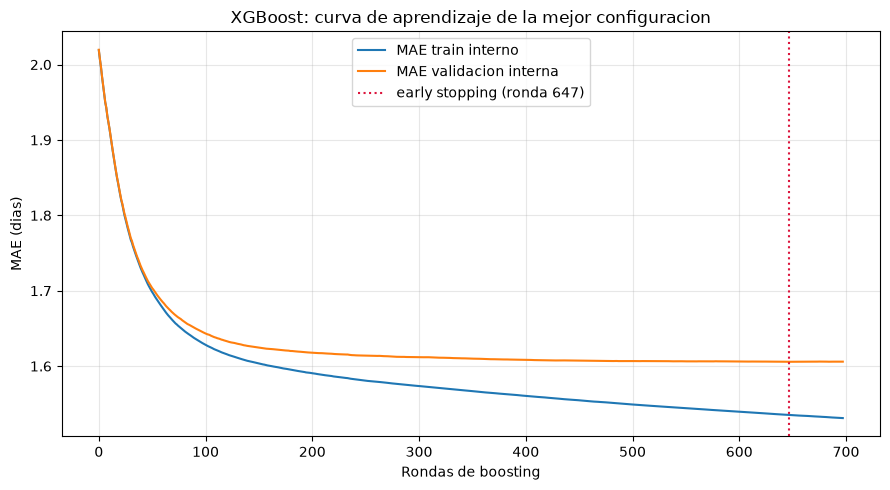

In [6]:
# --- Curva de aprendizaje de la mejor configuracion ---
import matplotlib.pyplot as plt

m_curva = XGBRegressor(
    objective=objetivo_elegido, n_estimators=3000,
    eval_metric="mae", early_stopping_rounds=50,
    tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
    **estudio_xgb.best_params,
)
m_curva.fit(
    Xt_tr2, y_tr2,
    eval_set=[(Xt_tr2, y_tr2), (Xt_val, y_val)], verbose=False,
)
historial = m_curva.evals_result()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(historial["validation_0"]["mae"], label="MAE train interno")
ax.plot(historial["validation_1"]["mae"], label="MAE validacion interna")
ax.axvline(m_curva.best_iteration, color="crimson", linestyle=":",
           label=f"early stopping (ronda {m_curva.best_iteration})")
ax.set_xlabel("Rondas de boosting")
ax.set_ylabel("MAE (dias)")
ax.set_title("XGBoost: curva de aprendizaje de la mejor configuracion")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# --- XGBoost final: refit sobre TODO el train con las rondas del early stopping ---
from sklearn.pipeline import Pipeline

pipe_xgb = Pipeline([
    ("preprocesador", build_preprocessor(scale=False)),
    ("modelo", XGBRegressor(
        objective=objetivo_elegido,
        n_estimators=max(mejor_ronda, 1),
        tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
        **estudio_xgb.best_params,
    )),
])
t0 = time.perf_counter()
pipe_xgb.fit(X_train, y_train)
t_xgb_refit = time.perf_counter() - t0

metricas_xgb = evaluar(pipe_xgb, X_test, y_test)
metricas_xgb["tiempo_s"] = round(t_xgb_refit, 2)
registrar(
    "xgboost", metricas_xgb,
    notas=(f"XGB objective={objetivo_elegido}, {estudio_xgb.best_params}, "
           f"n_estimators={mejor_ronda} (early stopping en val interna 10% del train); "
           f"TPE {len(estudio_xgb.trials)} trials ({t_xgb_busqueda/60:.0f} min)"),
)
print({k: round(v, 4) for k, v in metricas_xgb.items()})

{'mae': 1.7463, 'rmse': 2.4176, 'r2': 0.344, 'pred_test_s': 0.12, 'tiempo_s': 11.55}


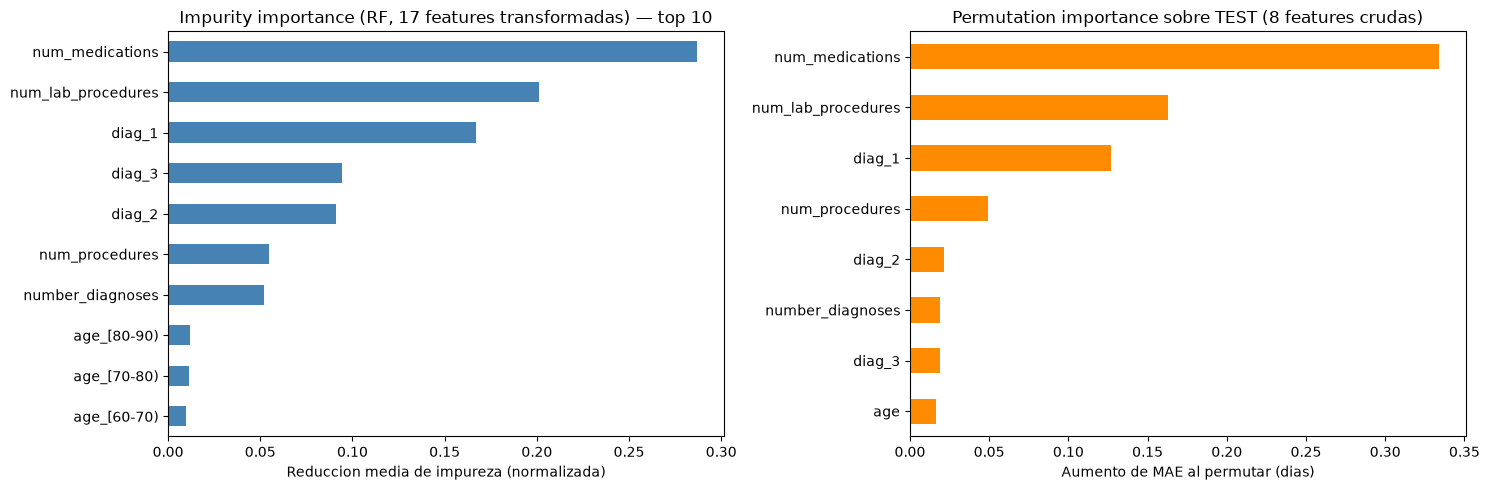

(permutation: 10 repeticiones x 8 columnas en 0.8 min, seed 42)

Top-10 impurity:
num_medications       0.2871
num_lab_procedures    0.2009
diag_1                0.1671
diag_3                0.0943
diag_2                0.0908
num_procedures        0.0545
number_diagnoses      0.0520
age_[80-90)           0.0121
age_[70-80)           0.0116
age_[60-70)           0.0095

Permutation (8 crudas):
num_medications       0.3341
num_lab_procedures    0.1632
diag_1                0.1267
num_procedures        0.0493
diag_2                0.0214
number_diagnoses      0.0188
diag_3                0.0187
age                   0.0162


In [8]:
# --- 3.3 Feature importance: impurity (RF) + permutation sobre TEST ---
import numpy as np
from sklearn.inspection import permutation_importance

# (1) Impurity del RF final: sobre las 17 columnas transformadas
nombres_17 = list(pipe_rf.named_steps["preprocesador"].get_feature_names_out())
imp_impurity = pd.Series(
    pipe_rf.named_steps["modelo"].feature_importances_, index=nombres_17
).sort_values(ascending=False)

# (2) Permutation importance sobre el TEST: sobre las 8 columnas crudas
#     (permuta las columnas de entrada del pipeline completo; el test se usa
#      SOLO para medir la caida de performance, no para elegir nada)
t0 = time.perf_counter()
perm = permutation_importance(
    pipe_rf, X_test, y_test, n_repeats=10,
    random_state=SEED, scoring="neg_mean_absolute_error", n_jobs=-1,
)
t_perm = time.perf_counter() - t0
imp_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp_impurity.head(10)[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Impurity importance (RF, 17 features transformadas) — top 10")
axes[0].set_xlabel("Reduccion media de impureza (normalizada)")
imp_perm[::-1].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Permutation importance sobre TEST (8 features crudas)")
axes[1].set_xlabel("Aumento de MAE al permutar (dias)")
plt.tight_layout(); plt.show()

print(f"(permutation: 10 repeticiones x 8 columnas en {t_perm/60:.1f} min, seed {SEED})")
print("\nTop-10 impurity:"); print(imp_impurity.head(10).round(4).to_string())
print("\nPermutation (8 crudas):"); print(imp_perm.round(4).to_string())

### Lectura hospitalaria del feature importance

*(Los valores exactos están arriba; esta lectura se basa en el orden que producen ambos métodos.)*

- **`num_medications` y `num_lab_procedures`** — la intensidad de tratamiento y de diagnóstico del encuentro — son los predictores dominantes en ambos métodos: más fármacos distintos y más análisis de laboratorio señalan un paciente clínicamente más complejo, que ocupa cama más días. Para la gestión: son variables disponibles desde las primeras horas de la admisión, así que el modelo puede correr temprano.
- **`number_diagnoses`** (cantidad de diagnósticos registrados) aporta en la misma dirección: comorbilidad ⇒ estadía más larga.
- **Los diagnósticos ICD-9 (`diag_1/2/3`)**: acá los dos métodos pueden discrepar, y la razón es conocida — la **impurity importance está sesgada hacia features de alta cardinalidad o continuas**: los `diag_*` pasan por TargetEncoder y llegan al bosque como variables continuas con muchos valores distintos, lo que les da más oportunidades de corte y infla su importancia aparente. La permutation importance sobre el test — que mide caída real de performance — es el árbitro honesto: si permutar `diag_1` apenas mueve el MAE, su contribución marginal es menor de lo que la impurity sugiere (probablemente porque la señal clínica ya está parcialmente capturada por la intensidad de tratamiento).
- **`age`**: la edad reparte su efecto entre 10 dummies en la vista de impurity (se subestima por fragmentación), mientras la permutation la evalúa como columna única — otra fuente esperable de discrepancia entre métodos, en sentido inverso a la de los diagnósticos.
- **`num_procedures`** (procedimientos quirúrgicos) suele quedar al fondo: en esta población diabética la mayoría de los encuentros son clínicos, no quirúrgicos.

**Implicación de negocio:** un sistema de alerta temprana de estadía prolongada puede construirse casi por completo con variables administrativas de disponibilidad inmediata (medicaciones, laboratorio, número de diagnósticos), sin esperar codificación ICD-9 definitiva — que en muchos hospitales se completa días después del alta.

## Cierre

Quedan registrados `random_forest` y `xgboost` en `resultados/metricas.csv` (9 filas). El notebook 07 arma la tabla comparativa final y la lectura global.

**Siguiente notebook (07):** comparación final — ¿quién gana, por cuánto, y a qué costo?